In [1]:
import os, pickle, tempfile
import pandas as pd

In [2]:
import sys

sys.path.append("../../training_data")

In [3]:
from utils.utils import Cif, CifFileWriter
from utils.pocket_utils import Pocket

# Data

In [4]:
ups = (
    ("7gqu", "q14191"), # done
    ("8qni", "Q13191"),
    ("8v81", "P13569"),
    ("8jp0", "P32418"),
    ("7yg5", "Q15878")
    # 8f4s not available
    # 8aq6 dimer not available
    # 8uk6 already included
)

## Collect results

In [5]:
news = {}

for holo, pdb_id, jobid, jobdir in (
    ("7gqu", "af-q14191-f1", "af-q14191-f1_out_1153095567726851806", "af-q14191-f1_out_1153095567726851806-A-2025-12-18-17-38-34-214912-c9ilpwzxalt"),
    ("8qni", "af-q13191-f1", "af-q13191-f1_out_-184824251272106742", "af-q13191-f1_out_-184824251272106742-A-2025-12-18-18-20-17-843186-5595101188430149814"),
    ("8v81", "af-p13569-f1", "af-p13569-f1_out_5062893454687777811", "af-p13569-f1_out_5062893454687777811-A-2025-12-18-18-23-47-374313-8974034245740134829"),
    ("8jp0", "af-p32418-f1", "af-p32418-f1_out_-121382155796052104", "af-p32418-f1_out_-121382155796052104-A-2025-12-18-19-05-07-618763-3016327104239585995"),
    ("7yg5", "af-q15878-f1", "af-q15878-f1_out_8248982329038707866", "af-q15878-f1_out_8248982329038707866-A-2025-12-18-19-16-13-776440-3338984357806762671")
    # ("8uk6", "af-q14191-f1", "af-q14191-f1-A-2025-12-18-14-32-07-067312-gpn757ep4vl"),
):
    path = f"../../../AlloPockets/gradio/{jobid}/{jobdir}"
    pockets_out = f"{path}/{jobid}/{jobid}_out" # /{pdb_id}_out.cif
    news[holo] = dict(
        pdb_id = pdb_id,
        jobid = jobid,
        path = path,
        predsf = f"{path}/predictions.csv",
        # pockets_out = pockets_out,
        pocketsf = f"{pockets_out}/{jobid}_out.cif",
        pocketsdir = f"{pockets_out}/pockets"
    )

# news["8uk6"] = dict(
#     pdb_id = "AF-A0A1D8PQM9-F1".lower(),
#     # path = path,
#     # predsf = f"{path}/predictions.csv",
#     # pockets_out = pockets_out,
#     pocketsf = f"../../training_data/8.Apos/Extra_set/pockets/AF-A0A1D8PQM9-F1/AF-A0A1D8PQM9-F1_out/AF-A0A1D8PQM9-F1_out.cif",
#     pocketsdir = f"../../training_data/8.Apos/Extra_set/pockets/AF-A0A1D8PQM9-F1/AF-A0A1D8PQM9-F1_out/pockets"
# )

news

{'7gqu': {'pdb_id': 'af-q14191-f1',
  'jobid': 'af-q14191-f1_out_1153095567726851806',
  'path': '../../../AlloPockets/gradio/af-q14191-f1_out_1153095567726851806/af-q14191-f1_out_1153095567726851806-A-2025-12-18-17-38-34-214912-c9ilpwzxalt',
  'predsf': '../../../AlloPockets/gradio/af-q14191-f1_out_1153095567726851806/af-q14191-f1_out_1153095567726851806-A-2025-12-18-17-38-34-214912-c9ilpwzxalt/predictions.csv',
  'pocketsf': '../../../AlloPockets/gradio/af-q14191-f1_out_1153095567726851806/af-q14191-f1_out_1153095567726851806-A-2025-12-18-17-38-34-214912-c9ilpwzxalt/af-q14191-f1_out_1153095567726851806/af-q14191-f1_out_1153095567726851806_out/af-q14191-f1_out_1153095567726851806_out.cif',
  'pocketsdir': '../../../AlloPockets/gradio/af-q14191-f1_out_1153095567726851806/af-q14191-f1_out_1153095567726851806-A-2025-12-18-17-38-34-214912-c9ilpwzxalt/af-q14191-f1_out_1153095567726851806/af-q14191-f1_out_1153095567726851806_out/pockets'},
 '8qni': {'pdb_id': 'af-q13191-f1',
  'jobid': 'af-

## Sites

In [6]:
with open("../../training_data/7.Extra_set/news_sites.pkl", "rb") as f:
    news_sites = pickle.load(f) # {k: v for k, v in pickle.load(f).items() if k in ("7gqu", "8qni", "8v81", "8jp0", "7yg5")}

len(news_sites), news_sites["7gqu"]

(25,
 [{'mod':      label_comp_id label_asym_id label_entity_id label_seq_id  \
   3420           X1L             D               4            .   
   
        pdbx_PDB_ins_code auth_seq_id auth_comp_id auth_asym_id  \
   3420                 ?        1002          X1L            A   
   
        pdbx_PDB_model_num pdbx_label_index pdbx_sifts_xref_db_name  \
   3420                  1             1002                       ?   
   
        pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num pdbx_sifts_xref_db_res  
   3420                      ?                      ?                      ?  ,
   'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            VAL             A               1           55                 ?   
   1            MET             A               1           56                 ?   
   2            ALA             A               1           57                 ?   
   3            THR             A               1          18

In [7]:
news_sites = {
    f"af-{up_id.lower()}-f1": [news_sites[pdb_id][0]["site"][["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num", "pdbx_sifts_xref_db_res"]],]
    for pdb_id, up_id in ups
}

for pdb_id, up_id in ups:
    if pdb_id == "8jp0":
        up_id = f"af-{up_id.lower()}-f1"
        news_sites[up_id] = [(
            news_sites[up_id][0]
            .replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}})
            .loc[news_sites[up_id][0]["pdbx_sifts_xref_db_num"].astype(int) < 800]
        ),]

news_sites

{'af-q14191-f1': [   pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num pdbx_sifts_xref_db_res
  0                  Q14191                    570                      V
  1                  Q14191                    571                      M
  2                  Q14191                    572                      A
  3                  Q14191                    703                      T
  4                  Q14191                    704                      A
  5                  Q14191                    705                      T
  6                  Q14191                    706                      A
  7                  Q14191                    707                      S
  8                  Q14191                    711                      R
  9                  Q14191                    725                      I
  10                 Q14191                    726                      T
  11                 Q14191                    727                      C
  12                 Q

In [8]:
news_sites = {
    k: [{"site": cif.residues.merge(v[0])},]
    for k, v in news_sites.items()
    for cif in (Cif(k, f"{k}_out.cif"),)
}

news_sites

{'af-q14191-f1': [{'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            VAL             A               1          570                 ?   
   1            MET             A               1          571                 ?   
   2            ALA             A               1          572                 ?   
   3            THR             A               1          703                 ?   
   4            ALA             A               1          704                 ?   
   5            THR             A               1          705                 ?   
   6            ALA             A               1          706                 ?   
   7            SER             A               1          707                 ?   
   8            ARG             A               1          711                 ?   
   9            ILE             A               1          725                 ?   
   10           THR             A               1   

In [9]:
# assert all(len(sites) == 1 for sites in news_sites.values()), "Not all apos have a single annotated site"

### 8uk6

In [10]:
extra_site = pd.read_pickle("../other_tools_apos/8uk6_apo_site.pkl")
extra_site

[{'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
  0            GLY             A               1          262                 ?   
  1            PHE             A               1          263                 ?   
  2            LEU             A               1          264                 ?   
  3            HIS             A               1          265                 ?   
  4            HIS             A               1          268                 ?   
  5            GLY             A               1          493                 ?   
  6            THR             A               1          494                 ?   
  7            ILE             A               1          495                 ?   
  8            MET             A               1          496                 ?   
  9            SER             A               1          497                 ?   
  10           LYS             A               1          498                 ?

In [11]:
news_sites["AF-A0A1D8PQM9-F1".lower()] = extra_site

## Data

In [12]:
models = pd.read_pickle("models_lenient_labelling.pkl")

models

{'model5': {'results': {'af-q14191-f1': {'pocket1': {'prob': 0.6842876076698303,
     'residues':     label_comp_id label_asym_id label_seq_id pdbx_PDB_ins_code auth_seq_id  \
     0             ILE             A         1177                 ?        1177   
     2             GLN             A          608                 ?         608   
     4             ALA             A          831                 ?         831   
     6             ASN             A          829                 ?         829   
     7             ALA             A         1176                 ?        1176   
     ..            ...           ...          ...               ...         ...   
     177           TYR             A          839                 ?         839   
     182           GLN             A          850                 ?         850   
     187           ILE             A          883                 ?         883   
     196           ALA             A          841                 ?         8

In [13]:
colors = {
    "orange": "#D55E00".lower(),
    "green": "#009E73".lower(),
    "blue": "#0072B2".lower(),
    "yellow": "#F0E442".lower(),
    "lightblue": "#56B4E9".lower(),
    "grey": "#404040"
}

# Labelling

In [14]:
# Percentage of residues of "one" in "other"
get_overlap = lambda one, other: (
    len( one.merge(other) ) / len(one)
)

def get_label(overlaps, site_in_pocket=None, pocket_in_site=None):
    assert not (site_in_pocket==None and pocket_in_site==None)
    
    if site_in_pocket is None:
        return int( overlaps["pocket_in_site"] >= pocket_in_site )
    if pocket_in_site is None:
        return int( overlaps["site_in_pocket"] >= site_in_pocket )
    return int( overlaps["site_in_pocket"] >= site_in_pocket or overlaps["pocket_in_site"] >= pocket_in_site )

In [15]:
get_overlaps = lambda pdb, pocketd: max(
    (
        {
            name: get_overlap(*one_in_other)
            for name, one_in_other in (
                ("pocket_in_site", (pocketd["residues"], site["site"])),
                ("site_in_pocket", (site["site"], pocketd["residues"])),
            )
        }
        for site in news_sites[pdb]
    ),
    key=lambda x: x["site_in_pocket"]
)
def get_overlaps_special(a,b): 
    raise Exception("This function should not be called")

In [16]:
def label_results(resultsd, site_in_pocket=0.35, pocket_in_site=None, prob_key=None, topx=False, special_7sns_sc=False):
    df = pd.DataFrame((
        {
            "pdb": pdb,
            "pocket": pocket,
            **{"prob": pocketd[prob_key] for prob_key in (prob_key,) if prob_key is not None},
            # "pred": pocketd["pred"],
            "label": get_label(overlaps, site_in_pocket, pocket_in_site),
            "max_overlap": max(overlaps.values()),
            **overlaps,
        }
        for pdb, pockets in resultsd.items()
            # if pdb != "4jqi"
        for pocket, pocketd in pockets.items()
        for overlaps in ((
            get_overlaps_special(pdb, pocketd)
            if special_7sns_sc and pdb == "7sns"
            else get_overlaps(pdb, pocketd)
        ),)
    ))
    
    if prob_key is not None and topx:
        df["pred"] = (
            # Start from a Series where each value/row (sample/pocket) is the total number of pos. labels on its PDB
            df.groupby("pdb")["label"].transform(lambda x: 3) #"sum")
            # Then subtract this "total num. of pos. in a PDB" by the rank of each pocket in a PDB, sorted by the probability
            .sub(df.groupby("pdb")["prob"].rank(method="first", ascending=False))
            # If the subtraction is positive or 0 it means that the pocket is in the topX and will be assigned 1
            >= 0
        ).astype(int)
        df["rank"] = (
            (df.groupby("pdb")["prob"].rank(method="first", ascending=False))
        ).astype(int)
        
        # If a PDB has no + labelled pocket, assign the highest prob. as positive
        for pdb, group in df.groupby("pdb"):
            if group["pred"].sum() == 0:
                df.loc[ group["prob"].idxmax(), "pred" ] = 1
    
    return df.sort_values("max_overlap", ascending=False)

In [17]:
for model, modeld in models.items():
    df = label_results(
        modeld["results"], 
        **modeld["labelling"], 
        prob_key=modeld["prob_key"],
        topx=True
    )
    
    # if model not in ["model5", "mefallosite", "allo"]: continue

    
    # if model != "model5":
    #     models[model]["labelled"] = label_results(
    #         modeld["results"], 
    #         **modeld["labelling"], 
    #         prob_key=modeld["prob_key"],
    #         topx=True
    #     )
    # else:
    #     # models[model]["labelled"] = label_our_results(
    #     #     modeld["results"], 
    #     #     # **modeld["labelling"]
    #     # )
    #     df = pd.DataFrame((
    #         {
    #             "pdb": pdb,
    #             "pocket": pocket,
    #             **pocketd
    #         }
    #         for pdb, pockets in modeld["results"].items()
    #             # if pdb != "4jqi"
    #         for pocket, pocketd in pockets.items()
    #     ))
        
    df["pred"] = (
        # Start from a Series where each value/row (sample/pocket) is the total number of pos. labels on its PDB
        df.groupby("pdb")["label"].transform(lambda x: 3) #"sum")
        # Then subtract this "total num. of pos. in a PDB" by the rank of each pocket in a PDB, sorted by the probability
        .sub(df.groupby("pdb")["prob"].rank(method="first", ascending=False))
        # If the subtraction is positive or 0 it means that the pocket is in the topX and will be assigned 1
        >= 0
    ).astype(int)
    
    df["rank"] = (
        (df.groupby("pdb")["prob"].rank(method="first", ascending=False))
    ).astype(int)

    models[model]["labelled"] = df
    #     # If a PDB has no + labelled pocket, assign the highest prob. as positive
    #     for pdb, group in df.groupby("pdb"):
    #         if group["pred"].sum() == 0:
    #             df.loc[ group["prob"].idxmax(), "pred" ] = 1

    #     models[model]["labelled"] = df

In [18]:
models["model5"]["labelled"]

,pdb,pocket,prob,label,max_overlap,pocket_in_site,site_in_pocket,pred,rank
53,af-p13569-f1,pocket3,0.178850,1,0.888889,0.489796,0.888889,1,2
15,af-q14191-f1,pocket21,0.000332,1,0.846154,0.846154,0.379310,0,16
42,af-q13191-f1,pocket1,0.000000,1,0.666667,0.392157,0.666667,1,2
179,af-q15878-f1,pocket21,0.000428,0,0.666667,0.666667,0.206897,0,36
9,af-q14191-f1,pocket5,0.000937,0,0.600000,0.600000,0.310345,0,10
...,...,...,...,...,...,...,...,...,...
91,af-p13569-f1,pocket31,0.000072,0,0.000000,0.000000,0.000000,0,40
92,af-p13569-f1,pocket49,0.000057,0,0.000000,0.000000,0.000000,0,41
93,af-p13569-f1,pocket52,0.000047,0,0.000000,0.000000,0.000000,0,42
94,af-p13569-f1,pocket56,0.000031,0,0.000000,0.000000,0.000000,0,43


In [19]:
models["model5"]["labelled"].sort_values("pred", ascending=False)

,pdb,pocket,prob,label,max_overlap,pocket_in_site,site_in_pocket,pred,rank
146,af-q15878-f1,pocket85,5.471402e-01,0,0.0,0.0,0.0,1,3
144,af-q15878-f1,pocket2,8.890489e-01,0,0.0,0.0,0.0,1,1
114,af-p32418-f1,pocket31,5.752990e-01,0,0.0,0.0,0.0,1,2
115,af-p32418-f1,pocket25,3.346274e-01,0,0.0,0.0,0.0,1,3
1,af-q14191-f1,pocket11,2.303604e-01,0,0.0,0.0,0.0,1,2
...,...,...,...,...,...,...,...,...,...
10,af-q14191-f1,pocket9,7.185192e-04,0,0.0,0.0,0.0,0,11
11,af-q14191-f1,pocket26,6.211752e-04,0,0.0,0.0,0.0,0,12
228,af-q15878-f1,pocket57,1.006171e-10,0,0.0,0.0,0.0,0,85
213,af-q15878-f1,pocket10,2.393536e-06,0,0.0,0.0,0.0,0,70


## 8uk6

In [20]:
extra_apo = pd.read_pickle("../other_tools_apos/8uk6_apo.pkl")
extra_apo

,pdb,pocket,prob,pred,label,max_overlap,pocket_in_site,site_in_pocket
233,AF-A0A1D8PQM9-F1,pocket16,5.919867e-02,0,0,0.000000,0.000000,0.000000
234,AF-A0A1D8PQM9-F1,pocket28,4.432872e-08,0,0,0.000000,0.000000,0.000000
235,AF-A0A1D8PQM9-F1,pocket18,1.105843e-03,0,0,0.000000,0.000000,0.000000
236,AF-A0A1D8PQM9-F1,pocket11,4.910578e-02,0,0,0.000000,0.000000,0.000000
237,AF-A0A1D8PQM9-F1,pocket25,2.220843e-04,0,0,0.000000,0.000000,0.000000
238,AF-A0A1D8PQM9-F1,pocket15,2.263395e-03,0,0,0.000000,0.000000,0.000000
239,AF-A0A1D8PQM9-F1,pocket7,2.715911e-04,0,0,0.000000,0.000000,0.000000
240,AF-A0A1D8PQM9-F1,pocket22,1.971535e-05,0,0,0.000000,0.000000,0.000000
241,AF-A0A1D8PQM9-F1,pocket13,6.159594e-05,0,0,0.000000,0.000000,0.000000
242,AF-A0A1D8PQM9-F1,pocket23,1.340654e-05,0,0,0.000000,0.000000,0.000000


In [21]:
extra_apo["pdb"] = "AF-A0A1D8PQM9-F1".lower()

extra_apo["pred"] = (
    # Start from a Series where each value/row (sample/pocket) is the total number of pos. labels on its PDB
    extra_apo.groupby("pdb")["label"].transform(lambda x: 3) #"sum")
    # Then subtract this "total num. of pos. in a PDB" by the rank of each pocket in a PDB, sorted by the probability
    .sub(extra_apo.groupby("pdb")["prob"].rank(method="first", ascending=False))
    # If the subtraction is positive or 0 it means that the pocket is in the topX and will be assigned 1
    >= 0
).astype(int)

extra_apo["rank"] = (
    (extra_apo.groupby("pdb")["prob"].rank(method="first", ascending=False))
).astype(int)

extra_apo

,pdb,pocket,prob,pred,label,max_overlap,pocket_in_site,site_in_pocket,rank
233,af-a0a1d8pqm9-f1,pocket16,5.919867e-02,0,0,0.000000,0.000000,0.000000,5
234,af-a0a1d8pqm9-f1,pocket28,4.432872e-08,0,0,0.000000,0.000000,0.000000,28
235,af-a0a1d8pqm9-f1,pocket18,1.105843e-03,0,0,0.000000,0.000000,0.000000,13
236,af-a0a1d8pqm9-f1,pocket11,4.910578e-02,0,0,0.000000,0.000000,0.000000,6
237,af-a0a1d8pqm9-f1,pocket25,2.220843e-04,0,0,0.000000,0.000000,0.000000,18
238,af-a0a1d8pqm9-f1,pocket15,2.263395e-03,0,0,0.000000,0.000000,0.000000,12
239,af-a0a1d8pqm9-f1,pocket7,2.715911e-04,0,0,0.000000,0.000000,0.000000,16
240,af-a0a1d8pqm9-f1,pocket22,1.971535e-05,0,0,0.000000,0.000000,0.000000,23
241,af-a0a1d8pqm9-f1,pocket13,6.159594e-05,0,0,0.000000,0.000000,0.000000,20
242,af-a0a1d8pqm9-f1,pocket23,1.340654e-05,0,0,0.000000,0.000000,0.000000,24


In [22]:
models["model5"]["labelled"] = pd.concat((
    models["model5"]["labelled"],
    extra_apo
))

models["model5"]["labelled"]

,pdb,pocket,prob,label,max_overlap,pocket_in_site,site_in_pocket,pred,rank
53,af-p13569-f1,pocket3,0.178850,1,0.888889,0.489796,0.888889,1,2
15,af-q14191-f1,pocket21,0.000332,1,0.846154,0.846154,0.379310,0,16
42,af-q13191-f1,pocket1,0.000000,1,0.666667,0.392157,0.666667,1,2
179,af-q15878-f1,pocket21,0.000428,0,0.666667,0.666667,0.206897,0,36
9,af-q14191-f1,pocket5,0.000937,0,0.600000,0.600000,0.310345,0,10
...,...,...,...,...,...,...,...,...,...
258,af-a0a1d8pqm9-f1,pocket3,0.075104,0,0.238095,0.185185,0.238095,0,4
259,af-a0a1d8pqm9-f1,pocket12,0.000049,0,0.000000,0.000000,0.000000,0,21
260,af-a0a1d8pqm9-f1,pocket19,0.455054,0,0.250000,0.250000,0.142857,1,2
261,af-a0a1d8pqm9-f1,pocket21,0.160090,0,0.000000,0.000000,0.000000,1,3


In [115]:
models["model5"]["labelled"].query("rank < 3")

,pdb,pocket,prob,label,max_overlap,pocket_in_site,site_in_pocket,pred,rank
53,af-p13569-f1,pocket3,0.178850,1,0.888889,0.489796,0.888889,1,2
42,af-q13191-f1,pocket1,0.000000,1,0.666667,0.392157,0.666667,1,2
113,af-p32418-f1,pocket24,0.576279,1,0.350000,0.145833,0.350000,1,1
145,af-q15878-f1,pocket1,0.868856,0,0.206897,0.077922,0.206897,1,2
52,af-p13569-f1,pocket1,1.000000,0,0.148148,0.011019,0.148148,1,1
0,af-q14191-f1,pocket1,0.684288,0,0.137931,0.065574,0.137931,1,1
144,af-q15878-f1,pocket2,0.889049,0,0.000000,0.000000,0.000000,1,1
1,af-q14191-f1,pocket11,0.230360,0,0.000000,0.000000,0.000000,1,2
40,af-q13191-f1,pocket10,0.000005,0,0.000000,0.000000,0.000000,1,1
114,af-p32418-f1,pocket31,0.575299,0,0.000000,0.000000,0.000000,1,2


# Scatters

## Ortho sites

In [23]:
apos = {
    holo: f"af-{up_id}-f1".lower()
    for holo, up_id in ups
}

apos

{'7gqu': 'af-q14191-f1',
 '8qni': 'af-q13191-f1',
 '8v81': 'af-p13569-f1',
 '8jp0': 'af-p32418-f1',
 '7yg5': 'af-q15878-f1'}

In [24]:
ortho_sites = pd.read_pickle("../other_tools/ortho_sites.pkl")
ortho_sites.keys(), ortho_sites

(dict_keys(['7gqu', '8v81', '8f4s', '8aq6', '8uk6']),
 {'7gqu': [   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            LEU             A               1           25                 ?   
   1            HIS             A               1           31                 ?   
   2            SER             A               1           32                 ?   
   3            SER             A               1           33                 ?   
   4            PHE             A               1           34                 ?   
   5            LYS             A               1           35                 ?   
   6            GLN             A               1           38                 ?   
   7            ALA             A               1           57                 ?   
   8            THR             A               1           58                 ?   
   9            GLY             A               1           59                 ?   
   10         

In [25]:
len(ortho_sites["8v81"]), ortho_sites["8v81"]

(2,
 [   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
  0            ASP             A               1          171                 ?   
  1            TRP             A               1          399                 ?   
  2            GLU             A               1          400                 ?   
  3            VAL             A               1          438                 ?   
  4            GLY             A               1          456                 ?   
  5            SER             A               1          457                 ?   
  6            THR             A               1          458                 ?   
  7            GLY             A               1          459                 ?   
  8            ALA             A               1          460                 ?   
  9            GLY             A               1          461                 ?   
  10           LYS             A               1          462                 ?   


In [26]:
len(ortho_sites["8aq6"]), ortho_sites["8aq6"]

(2,
 [   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
  0            TYR             G               1           28                 ?   
  1            ASN             G               1           29                 ?   
  2            LEU             G               1           30                 ?   
  3            VAL             G               1           33                 ?   
  4            LEU             G               1           34                 ?   
  5            LEU             G               1           42                 ?   
  6            PHE             G               1           43                 ?   
  7            GLN             G               1           44                 ?   
  8            LEU             G               1           46                 ?   
  9            GLY             G               1           47                 ?   
  10           VAL             G               1           48                 ?   


In [27]:
ortho_sites = {
    apo: [
        chainres
        for osite in osites
        for chain, chainres in apocif.residues.merge(
            osite[["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]].drop_duplicates()
        ).groupby("label_asym_id")
    ]
    for holo, osites in ortho_sites.items()
        if holo in apos
            for apo in (apos[holo],)
            for apocif in (Cif(news[holo]["jobid"], f'{news[holo]["path"]}/{news[holo]["jobid"]}.cif'),)
}

len(ortho_sites), ortho_sites

(2,
 {'af-q14191-f1': [   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            LEU             A               1          540                 ?   
   1            HIS             A               1          546                 ?   
   2            SER             A               1          547                 ?   
   3            SER             A               1          548                 ?   
   4            PHE             A               1          549                 ?   
   5            LYS             A               1          550                 ?   
   6            GLN             A               1          553                 ?   
   7            ALA             A               1          572                 ?   
   8            THR             A               1          573                 ?   
   9            GLY             A               1          574                 ?   
   10           TYR             A               1       

In [28]:
ortho_sites["AF-A0A1D8PQM9-F1".lower()] = pd.read_pickle("../other_tools_apos/8uk6_apo_orthosite.pkl")
ortho_sites["AF-A0A1D8PQM9-F1".lower()]

[   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
 0            ARG             A               1          255                 ?   
 1            PHE             A               1          256                 ?   
 2            PRO             A               1          257                 ?   
 3            PRO             A               1          258                 ?   
 4            GLU             A               1          259                 ?   
 5            PRO             A               1          260                 ?   
 6            ASN             A               1          261                 ?   
 7            GLY             A               1          267                 ?   
 8            HIS             A               1          268                 ?   
 9            LYS             A               1          270                 ?   
 10           ALA             A               1          271                 ?   
 11           AS

In [29]:
[(k, len(v)) for k, v in ortho_sites.items()]

[('af-q14191-f1', 1), ('af-p13569-f1', 2), ('af-a0a1d8pqm9-f1', 1)]

In [30]:
ortho_labels = {}

for pdb, pdbd in models["model5"]["results"].items():
    if pdb not in ortho_sites: continue
    
    paths = [v for v in news.values() if v["pdb_id"] == pdb][0]
        
    ortho_sites_pdb = ortho_sites[pdb]
    ortho_labels[pdb] = {}
    
    for pocket, pocketd in pdbd.items():
        pocketres = Pocket(f"{paths['pocketsdir']}/{pocket}_atm.cif").residues

        overlaps = max(
            (
                {
                    name: get_overlap(*one_in_other)
                        for name, one_in_other in (
                            ("pocket_in_site", (pocketres, site)),
                            ("site_in_pocket", (site, pocketres)),
                        )
                }
                for site in ortho_sites_pdb
            ),
            key=lambda x: x["site_in_pocket"]
        )
        
        ortho_labels[pdb][pocket] = {
            "ortho_label": get_label(overlaps, site_in_pocket=0.65, pocket_in_site=None),
            "ortho_max_overlap": max(overlaps.values()),
            **{f"ortho_{k}": v for k, v in overlaps.items()},
            **pocketd
        }

ortho_labels.keys(), ortho_labels

(dict_keys(['af-q14191-f1', 'af-p13569-f1']),
 {'af-q14191-f1': {'pocket1': {'ortho_label': 0,
    'ortho_max_overlap': 0.047619047619047616,
    'ortho_pocket_in_site': 0.01639344262295082,
    'ortho_site_in_pocket': 0.047619047619047616,
    'prob': 0.6842876076698303,
    'residues':     label_comp_id label_asym_id label_seq_id pdbx_PDB_ins_code auth_seq_id  \
    0             ILE             A         1177                 ?        1177   
    2             GLN             A          608                 ?         608   
    4             ALA             A          831                 ?         831   
    6             ASN             A          829                 ?         829   
    7             ALA             A         1176                 ?        1176   
    ..            ...           ...          ...               ...         ...   
    177           TYR             A          839                 ?         839   
    182           GLN             A          850           

In [31]:
pd.DataFrame((
    {
        "pdb": pdb,
        "pocket": pocket,
        **pocketd
    }
    for pdb, pockets in ortho_labels.items()
    for pocket, pocketd in pockets.items()
)).sort_values("ortho_max_overlap", ascending=False).iloc[:40]

,pdb,pocket,ortho_label,ortho_max_overlap,ortho_pocket_in_site,ortho_site_in_pocket,prob,residues
40,af-p13569-f1,pocket1,1,0.892857,0.068871,0.892857,1.000000,label_comp_id label_asym_id label_seq_id ...
4,af-q14191-f1,pocket2,1,0.809524,0.404762,0.809524,0.005406,label_comp_id label_asym_id label_seq_id p...
3,af-q14191-f1,pocket14,0,0.588235,0.588235,0.476190,0.019046,label_comp_id label_asym_id label_seq_id pd...
89,af-p13569-f1,pocket10,0,0.333333,0.333333,0.107143,0.000009,label_comp_id label_asym_id label_seq_id pd...
87,af-p13569-f1,pocket35,0,0.300000,0.300000,0.096774,0.000016,label_comp_id label_asym_id label_seq_id pd...
69,af-p13569-f1,pocket39,0,0.277778,0.277778,0.161290,0.000255,label_comp_id label_asym_id label_seq_id pd...
55,af-p13569-f1,pocket30,0,0.250000,0.250000,0.142857,0.000807,label_comp_id label_asym_id label_seq_id pd...
28,af-q14191-f1,pocket13,0,0.222222,0.222222,0.095238,0.000033,label_comp_id label_asym_id label_seq_id pd...
57,af-p13569-f1,pocket38,0,0.187500,0.187500,0.107143,0.000771,label_comp_id label_asym_id label_seq_id pd...
37,af-q14191-f1,pocket28,0,0.181818,0.181818,0.095238,0.000003,label_comp_id label_asym_id label_seq_id pd...


In [32]:
ortho_pockets = {
    "af-p13569-f1": ("pocket1",),
    "af-q14191-f1": ("pocket2",),
    "af-a0a1d8pqm9-f1": ("pocket3",)
}

## Plots

In [33]:
df = models["model5"]["labelled"]

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import MaxNLocator
from sklearn.neighbors import NearestNeighbors

# ------------------------------------------------------------------
# CONFIGURATION (tune these)
# ------------------------------------------------------------------

# Figure size (inches)
fig_width  = 1.75
fig_height = 2.25

boxplot_widths = 0.4

# Reference size for which base_fs_ref was chosen
ref_fig_width  = 1.5
ref_fig_height = 2.5
base_fs_ref    = 12.5   # base font size for the reference figure size

# Scale fonts with figure size (use min so fonts don't explode if aspect changes)
size_scale = min(fig_width / ref_fig_width, fig_height / ref_fig_height)
base_fs    = base_fs_ref * size_scale

# Font sizes
fs_tick_factor  = 0.8
fs_label_factor = 1
# fs_title_factor = 1.4

fs_tick  = base_fs * fs_tick_factor
fs_label = base_fs * fs_label_factor
# fs_title = base_fs * fs_title_factor

# Scatter / box / axis styling
point_size       = 30            # size of scatter points
scatter_alpha    = 0.5

# How far in y we consider "neighbors" for crowding, as fraction of y-range
density_band_frac = 0.05   # e.g. 5% of the y-range
jitter_width     = 0.2          # horizontal jitter of points

text_offset_frac = 0.05         # vertical distance between max point and its label (fraction of y-range)
text_offset_frac_x = 0.4
box_linewidth    = 0.8           # boxplot line thickness
axis_linewidth   = 0.8           # axis spine thickness

# Y-tick control
n_yticks           = 5           # maximum number of y ticks
use_custom_yticks  = False       # set to True to use custom_yticks instead of automatic
custom_yticks      = [0.0, 0.25, 0.5, 0.75, 1.0]  # example, only used if use_custom_yticks=True

# Colors
light_grey   = "0.75"            # base color for points
# label_color  = "tab:orange"      # example color if label == 1
# pred_color   = "tab:blue"        # example color if pred == 1
# both_color   = "tab:green"       # example color if label == 1 and pred == 1

top_colors = ["blue", "lightblue", "grey"]

def point_color(row):
    pdb = row["pdb"]
    pred = row["pred"]
    rank = row["rank"]
    label = row["label"]
    if pdb in ortho_pockets:# and pdb != "6yhr":
        if row["pocket"] in ortho_pockets[row["pdb"]]:
            return colors["yellow"]
    if pred and label:
        return colors["green"]
    elif label:
        return colors["orange"]
    elif pred and rank <= 3:
        return rank-1
        # if rank == 1:
        #     return colors["blue"]
        # elif rank <= 3:
        #     "black"
    else:
        return light_grey

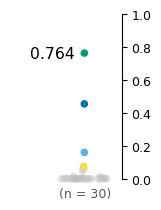

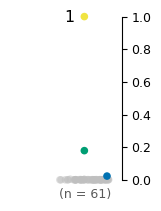

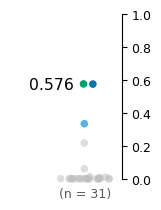

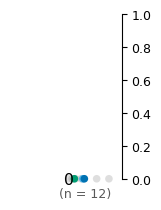

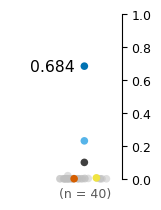

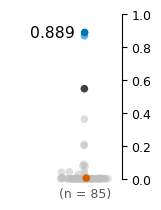

In [87]:
# Output
output_prefix = "boxplot_"       # files will be like "boxplot_7gqu.svg"

# ------------------------------------------------------------------
# Matplotlib global settings (text as text in SVG, transparent, etc.)
# ------------------------------------------------------------------

rcParams["font.size"] = base_fs
rcParams["ytick.labelsize"] = fs_tick
rcParams["svg.fonttype"] = "none"      # keep text as text, not paths -> nicer in PowerPoint
rcParams["axes.linewidth"] = axis_linewidth

# ------------------------------------------------------------------
# MAIN: loop over pdb and create one boxplot+scatter per pdb
# Assumes your dataframe is called `df` and has at least:
#   'pdb', 'prob', 'pred', 'label'
# ------------------------------------------------------------------

for pdb_id, sub in df.groupby("pdb"):
    sub = sub.copy()
    probs = sub["prob"].to_numpy()

    # Skip if no valid data
    if len(probs) == 0 or np.all(np.isnan(probs)):
        continue

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Y-limits (add some margin)
    y_min = np.nanmin(probs)
    y_max = np.nanmax(probs)
    if y_min == y_max:
        # if all equal, pad a bit
        if y_min == 0:
            y_min, y_max = -0.1, 0.1
        else:
            y_min *= 0.9
            y_max *= 1.1
    y_range = y_max - y_min
    # ax.set_ylim(y_min - 0.05 * y_range, y_max + 0.15 * y_range)
    ax.set_ylim(0, 1)

    # Scatter with jitter
    # x_vals = 0 + (np.random.rand(len(sub)) - 0.5) * 2 * jitter_width
    sc_colors = [point_color(row) for _, row in sub.iterrows()]
    for j, (i, c) in enumerate(sorted(
        ((i, c) for i, c in enumerate(sc_colors) if type(c) is int),
        key=lambda x: x[1]
    )):
        sc_colors[i] = colors[top_colors[j]]
        
    alphas = [
        scatter_alpha if c == light_grey else 1 
        for c in sc_colors
    ]

    # Beeswarm-like jitter
    counts = np.array([
        len(ind) for ind in NearestNeighbors(radius=density_band_frac*y_range)
        .fit(probs.reshape(-1,1))
        .radius_neighbors(probs.reshape(-1,1), return_distance=False)
    ])
    x_vals = (np.random.rand(len(probs))-0.5) * 2 * jitter_width * np.maximum(0, (counts-1)/(counts.max()-1+1e-12))
    # print(np.min(x_vals), np.max(x_vals))
    ax.set_xlim(-0.6, 0.3)

    x_vals   = np.asarray(x_vals)
    probs    = np.asarray(probs)
    sc_colors   = np.asarray(sc_colors)
    alphas   = np.asarray(alphas)
    
    bg = sc_colors == light_grey
    fg = ~bg

    if pdb_id == "af-p32418-f1":
        x_vals[fg] = np.asarray([
            x+0.075 if (
                sc_colors[fg][i] == colors["blue"]
                and probs[fg][i] > 0.5
            ) else x
            for i, x in enumerate(x_vals[fg]) 
        ])
    
    ax.scatter(x_vals[bg], probs[bg], s=point_size, c=sc_colors[bg],
               alpha=alphas[bg], edgecolors="none", zorder=1, clip_on=False)
    
    ax.scatter(x_vals[fg], probs[fg], s=point_size, c=sc_colors[fg],
               alpha=alphas[fg], edgecolors="none", zorder=3, clip_on=False)
    # ax.scatter(
    #     x_vals,
    #     probs,
    #     s=point_size,
    #     c=sc_colors,
    #     alpha=alphas,
    #     edgecolors="none",
    #     zorder=1,
    #     clip_on=False
    # )

    # Annotate max point
    idx_max = int(np.nanargmax(probs))
    x_max = x_vals[idx_max]
    y_max_point = probs[idx_max]

    # Format prob with up to 3 decimals, no trailing zeros
    text_val = f"{y_max_point:.3f}".rstrip("0").rstrip(".")

    ax.text(
        x_max - jitter_width * text_offset_frac_x,
        y_max_point - text_offset_frac,
        text_val,
        ha="right",
        va="bottom",
        fontsize=fs_label,
    )

    # # Boxplot: thin black lines, no fill
    # bp = ax.boxplot(
    #     probs,
    #     positions=[0],
    #     widths=boxplot_widths,
    #     vert=True,
    #     patch_artist=False,  # no box fill
    #     showfliers=False,
    #     whiskerprops=dict(color="black", linewidth=box_linewidth),
    #     capprops=dict(color="black", linewidth=box_linewidth),
    #     medianprops=dict(color="black", linewidth=box_linewidth),
    #     boxprops=dict(color="black", linewidth=box_linewidth),
    # )
    # for artist in bp['boxes'] + bp['whiskers'] + bp['caps'] + bp['medians']:
    #     artist.set_clip_on(False)

    # Remove all spines except right
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["right"].set_visible(True)
    ax.spines["right"].set_linewidth(axis_linewidth)

    # Axis formatting: vertical plot, ticks on the right only
    ax.set_xticks([])
    ax.tick_params(axis="x", which="both", length=0)

    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")

    if use_custom_yticks:
        ax.set_yticks(custom_yticks)
    else:
        ax.yaxis.set_major_locator(MaxNLocator(n_yticks))

    ax.tick_params(axis="y", labelsize=fs_tick)
    ax.set_ylabel("")
    # ax.set_title(pdb_id)

    # Transparent background (figure + axes)
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    ax.set_xlabel(f"(n = {len(sub)})", fontsize=fs_tick, color="0.35")
    ax.xaxis.set_label_coords(0.675, -0.05)
    
    plt.tight_layout()

    # Save as transparent SVG, ready for PowerPoint
    out_name = f"{output_prefix}{pdb_id}.svg"
    fig.savefig( out_name, dpi=300, transparent=True)
    plt.show()
    # break

In [36]:
apos

{'7gqu': 'af-q14191-f1',
 '8qni': 'af-q13191-f1',
 '8v81': 'af-p13569-f1',
 '8jp0': 'af-p32418-f1',
 '7yg5': 'af-q15878-f1'}

In [37]:
ortho_pockets

{'af-p13569-f1': ('pocket1',),
 'af-q14191-f1': ('pocket2',),
 'af-a0a1d8pqm9-f1': ('pocket3',)}

# Pocket functions

In [38]:
# from biotite.structure.io.pdb import PDBFile

# def get_pdb_atoms(f):
#     atom_array = PDBFile.read(f).get_structure()
#     return pd.DataFrame({
#             "auth_asym_id": atom_array.chain_id,
#             "auth_seq_id": atom_array.res_id,
#             "auth_comp_id": atom_array.res_name,
#             "auth_atom_id": atom_array.atom_name,
#             "type_symbol": atom_array.element,
#             "Cartn_x": atom_array.coord[0][:, 0],
#             "Cartn_y": atom_array.coord[0][:, 1],
#             "Cartn_z": atom_array.coord[0][:, 2],
#             "pdbx_PDB_ins_code": (ic or '?' for ic in atom_array.ins_code)
#         }, dtype=str)

In [39]:
# def get_pocket(pocket_atoms, res_id, color):
#     pocket_atoms["label_entity_id"] = '99'
#     return {
#         "pocketn": res_id,
#         "atoms": pocket_atoms, 
#         "representation": {
#             "selection": [{'label_entity_id': '99', "auth_asym_id": pocket_atoms.auth_asym_id.unique().item(), 'auth_seq_id': int(res_id)}], 
#             'color': colors[color]
#         }
#     }

In [40]:
def get_our_pocket(pdb, pocket, pocketsf, color):
    pocketn = pocket.replace('pocket', '')
    # pocket_atoms = (
    #     Cif(pdb, f"{extra_set_path}/pockets/{pdb}/{pdb}_out/{pdb}_out.cif", name=f"{pdb}_out")
    #     .atoms
    #     .query(f"label_comp_id == 'STP' and label_seq_id == '{pocketn}'")
    # )

    return {
        "pocketsf": pocketsf,#f"{extra_set_path}/pockets/{pdb}/{pdb}_out/{pdb}_out.cif",
        "pocketn": pocketn,
        "pocket_sel": [{"label_comp_id": 'STP', "label_seq_id": int(pocketn)},],
        "color": colors[color]
    }#get_pocket(pocket_atoms, pocketn, color)
# {
#         "atoms": pocket_atoms, 
#         "representation": {
#             "selection": {'label_entity_id': '99', "auth_asym_id": pocket_atoms.auth_asym_id.unique().item(), 'auth_seq_id': int(pocketn)}, 
#             'color': colors[color]
#         }
#     }

models["model5"]["pocketf"] = get_our_pocket

# View functions

In [41]:
import molviewspec as mvs
import json
from pathlib import Path

In [42]:
import numpy as np

In [43]:
paths

{'pdb_id': 'af-p13569-f1',
 'jobid': 'af-p13569-f1_out_5062893454687777811',
 'path': '../../../AlloPockets/gradio/af-p13569-f1_out_5062893454687777811/af-p13569-f1_out_5062893454687777811-A-2025-12-18-18-23-47-374313-8974034245740134829',
 'predsf': '../../../AlloPockets/gradio/af-p13569-f1_out_5062893454687777811/af-p13569-f1_out_5062893454687777811-A-2025-12-18-18-23-47-374313-8974034245740134829/predictions.csv',
 'pocketsf': '../../../AlloPockets/gradio/af-p13569-f1_out_5062893454687777811/af-p13569-f1_out_5062893454687777811-A-2025-12-18-18-23-47-374313-8974034245740134829/af-p13569-f1_out_5062893454687777811/af-p13569-f1_out_5062893454687777811_out/af-p13569-f1_out_5062893454687777811_out.cif',
 'pocketsdir': '../../../AlloPockets/gradio/af-p13569-f1_out_5062893454687777811/af-p13569-f1_out_5062893454687777811-A-2025-12-18-18-23-47-374313-8974034245740134829/af-p13569-f1_out_5062893454687777811/af-p13569-f1_out_5062893454687777811_out/pockets'}

In [44]:
news_sites.keys()

dict_keys(['af-q14191-f1', 'af-q13191-f1', 'af-p13569-f1', 'af-p32418-f1', 'af-q15878-f1', 'af-a0a1d8pqm9-f1'])

In [45]:
apos

{'7gqu': 'af-q14191-f1',
 '8qni': 'af-q13191-f1',
 '8v81': 'af-p13569-f1',
 '8jp0': 'af-p32418-f1',
 '7yg5': 'af-q15878-f1'}

In [75]:
# ass_fields_list = ["_pdbx_struct_assembly", "_pdbx_struct_assembly_gen", "_pdbx_struct_oper_list"]

def view_pockets(pdb, model, pockets:list):
    if pdb == "af-a0a1d8pqm9-f1":
        paths = {
            "pdb_id": "af-a0a1d8pqm9-f1",
            "jobid": "af-a0a1d8pqm9-f1".upper(),
            "path": "../../training_data/8.Apos/Extra_set/origcifs", # AF-A0A1D8PQM9-F1_updated.cif.gz
            # "predsf": 
            "pocketsf": "../../training_data/8.Apos/Extra_set/pockets/AF-A0A1D8PQM9-F1/AF-A0A1D8PQM9-F1_out/AF-A0A1D8PQM9-F1_out.cif",
            "pocketsdir": "../../training_data/8.Apos/Extra_set/pockets/AF-A0A1D8PQM9-F1/AF-A0A1D8PQM9-F1_out/pockets"
        }
    else:
        paths = [v for v in news.values() if v["pdb_id"] == pdb][0]
    
    cif = Cif(paths["jobid"], f"{paths['path']}/{paths['jobid']}_updated.cif.gz")

    # minimal_elements = lambda element="label_asym_id": site["site"][element].unique().tolist() + site["mod"][element].unique().tolist()

    site = news_sites[pdb][0]
    # if pdb == "8sgj":
    #     site["site"] = site["site"].loc[lambda x: x["label_seq_id"].astype(int) < 800]
    # elif pdb == "7sns" and model == "mefallosite":
    #     site = news_sites[pdb][1]
    
    # atoms = cif.atoms.query(f"label_asym_id in {minimal_elements('label_asym_id')}")

    # # Fake entity data
    # entities = pd.concat((
    #     pd.DataFrame(cif.cif.data["_entity"], dtype=str),#.query(f"id in {minimal_elements('label_entity_id')}"),
    #     pd.DataFrame([{"id": "99", "type": "branched", "pdbx_description": "pockets"}]) # Fake the pockets as carbohydrates to manage their representation
    # )).fillna(".")

    entities = pd.DataFrame(cif.cif.data["_entity"], dtype=str)

    # columns = list( set.intersection( *map(set, (pocket_atoms["atoms"].columns for pocket_atoms in pockets)) ) )
    # atoms = pd.concat((
    #     cif.atoms[columns],
    #     *(pocket_atoms["atoms"][columns] for pocket_atoms in pockets)
    # ))

    # with tempfile.NamedTemporaryFile("w+", suffix=".cif") as f:
    #     writer = CifFileWriter(f.name)
    #     writer.write({cif.entry_id.upper(): {
    #         "_entity": entities.to_dict(orient="list"),
    #         "_atom_site": atoms.to_dict(orient="list"),
    #         # **{k: cif.cif.data[k] for k in ass_fields_list}
    #     }})
    #     combined = Cif(pdb, filename=f.name)
    #     combined.cif.data # to cache it while 'f' exists

    
    builder = mvs.create_builder()
    transformation = custom_vizs[pdb]["camera"].get("transformation", None)
    if transformation is not None:
        transformation = transformation.get(model, transformation["transformation"])
        M = np.array(transformation).reshape(4,4,order="F")
        rot, trans = M[:3,:3].flatten(order="F").tolist(), M[:3,3].tolist()
        structure = (
            builder.download(url=f"{pdb}.cif")
            .parse(format="mmcif")
            .model_structure()
            .transform(rotation=rot, translation=trans)
        )
    else:
        structure = (
            builder.download(url=f"{pdb}.cif")
            .parse(format="mmcif")
            .model_structure()
        )

    assets = {f'{pdb}.cif': cif.cif.text.encode()}


    if custom_vizs[pdb]["camera"]["camera"]:
        builder.camera(
            **eval(
                "dict("
                + custom_vizs[pdb]["camera"]["camera"].strip()[1:-1].replace(":", "=") 
                + ")"
            )
        )
    if model in custom_vizs[pdb]["camera"]:
        builder.camera(
            **eval(
                "dict("
                + custom_vizs[pdb]["camera"][model].strip()[1:-1].replace(":", "=") 
                + ")"
            )
        )

    # Protein and site
    for auth_asym_id, siteres in site["site"].groupby("auth_asym_id"):
        protein = (
            structure
            .component(selector=[
                mvs.ComponentExpression(**sel)
                for sel in custom_vizs[pdb]["selections"].get(f"protein_{auth_asym_id}", [{"auth_asym_id": auth_asym_id},])
            ])
            .representation(type="cartoon", custom={"molstar_representation_params": {"ignoreLight": True}})#, custom={"ignoreLight": True})
            .color(color='#DADADA')
        )
        annos = f'annos_chain_{auth_asym_id}.json'
        assets[annos] = json.dumps(
            [
                {
                    'auth_asym_id': r["auth_asym_id"], 'auth_seq_id': int(r["auth_seq_id"]), 
                    'color': 'black' # 'pdbx_PDB_ins_code': r["pdbx_PDB_ins_code"],
                }
                for i, r in siteres.iterrows()
            ]
        ).encode()
        protein.color_from_uri(uri=annos, format='json', schema='all_atomic')

        if model == "model5":
            for i, osite in enumerate(ortho_sites.get(pdb, [])):
                osite = osite.query(f"auth_asym_id == '{auth_asym_id}'").merge(
                    siteres,
                    how="left", indicator=True
                ).query("_merge == 'left_only'").drop(columns="_merge")
                
                if len(osite) == 0: continue
                annos = f'ortho_annos_{auth_asym_id}_{i}.json'
                assets[annos] = json.dumps(
                    [
                        {
                            'auth_asym_id': r["auth_asym_id"], 'auth_seq_id': int(r["auth_seq_id"]), 
                            'color': colors["yellow"] # 'pdbx_PDB_ins_code': r["pdbx_PDB_ins_code"],
                        }
                        for i, r in osite.iterrows()
                    ]
                ).encode()
                protein.color_from_uri(uri=annos, format='json', schema='all_atomic')
                
            
    # # Ligands
    # if not custom_vizs[pdb]["ligands"]["none"]:
    #     for entity_id in entities.query("type == 'non-polymer'").id.unique():
    #         # if entity_id not in site["mod"].label_entity_id.unique():
    #         (
    #             structure
    #             .component(selector=mvs.ComponentExpression(label_entity_id=entity_id))
    #             .representation(type="ball_and_stick", custom={"molstar_representation_params": {"ignoreLight": True}})
    #             .color(color="white")
    #         )
    # if model in custom_vizs[pdb]["ligands"]:
    #     for lig in custom_vizs[pdb]["ligands"][model]:
    #         (
    #             structure
    #             .component(selector=mvs.ComponentExpression(**lig))
    #             .representation(
    #                 type="ball_and_stick", 
    #                 size_factor=custom_vizs[pdb]["ligands"].get("size_factor", 0.6),
    #                 custom={"molstar_representation_params": {"ignoreLight": True}})
    #             .color(
    #                 custom={
    #                     "molstar_color_theme_name": "element-symbol",
    #                     "molstar_color_theme_params": {
    #                         "carbonColor": { "name": "uniform", "params": {"value": int("#808080".replace('#', ''), 16)} }
    #                     }
    #                 }
    #             )
    #             # .opacity(opacity=0.9)
    #         )
    
    # # Modulator
    # # for entity_id in entities.query("type == 'non-polymer'").id.unique():
    # for entity_id in site["mod"].label_entity_id.unique():
    #     (
    #         structure
    #         .component(selector=mvs.ComponentExpression(label_entity_id=entity_id))
    #         .representation(
    #             type="ball_and_stick", 
    #             size_factor=custom_vizs[pdb]["ligands"].get("size_factor", 0.6),
    #             custom={"molstar_representation_params": {"ignoreLight": True}})
    #         .color(
    #             custom={
    #                 "molstar_color_theme_name": "element-symbol",
    #                 "molstar_color_theme_params": {
    #                     "carbonColor": { "name": "uniform", "params": {"value": int("#666666".replace('#', ''), 16)} }
    #                 }
    #             }
    #         )
    #         # .opacity(opacity=0.9)
    #     )



    # Pockets
    pockets_strs = {}
    for i, pocket in enumerate(pockets):
        pocketf = Path(paths["pocketsf"])
        name = pocketf.name
        if name not in assets:
            # if "transformation" in custom_vizs[pdb]["camera"]:
            if transformation is not None:
                pockets_strs[name] = (
                    builder.download(url=name)
                    .parse(format="mmcif" if pocketf.suffix == ".cif" else "pdb")
                    .model_structure()
                    .transform(rotation=rot, translation=trans)
                )
            else:
                pockets_strs[name] = (
                    builder.download(url=name)
                    .parse(format="mmcif" if pocketf.suffix == ".cif" else "pdb")
                    .model_structure()
                )
            with open(pocketf, "r") as f:
                assets[name] = f.read().encode()

        (
            pockets_strs[name]
            .component(selector=[
                mvs.ComponentExpression(**sel)
                for sel in pocket["pocket_sel"]
            ])
            .representation(type="surface", custom={"molstar_representation_params": {"ignoreLight": True}})
            .color(color=pocket["color"])
            .opacity(
                opacity=(
                    custom_vizs[pdb]["pocket_opacity"]
                    .get(model, {pocket["pocketn"]: 0.5})
                    .get(pocket["pocketn"], 0.5)
                )
            )
        )
    


    # View
    return mvs.MVSX(
        data=builder.get_state(),
        assets=assets
    )
    # v = mvsx.molstar_notebook(width= 1725, height= 875)
    # return v

In [76]:
def view_top(pdb, model, top=None):
    pocketf = models[model]["pocketf"]
    prob_key = models[model]["prob_key"]
    results = models[model]["results"].get(pdb, None)
    labelled = models[model]["labelled"].query(f"pdb == '{pdb}'").sort_values("prob", ascending=False)
    pos_pockets = labelled[labelled["label"] == 1]
    pdb_ortho_pockets = ortho_pockets.get(pdb, None)

    if pdb == "af-a0a1d8pqm9-f1":
        paths = {
            "pdb_id": "af-a0a1d8pqm9-f1",
            "jobid": "af-a0a1d8pqm9-f1",
            "path": "../../training_data/8.Apos/Extra_set/origcifs", # AF-A0A1D8PQM9-F1_updated.cif.gz
            # "predsf": 
            "pocketsf": "../../training_data/8.Apos/Extra_set/pockets/AF-A0A1D8PQM9-F1/AF-A0A1D8PQM9-F1_out/AF-A0A1D8PQM9-F1_out.cif",
            "pocketsdir": "../../training_data/8.Apos/Extra_set/pockets/AF-A0A1D8PQM9-F1/AF-A0A1D8PQM9-F1_out/pockets"
        }
    else:
        paths = [v for v in news.values() if v["pdb_id"] == pdb][0]

    if top is None:
        top = labelled["label"].sum() or 1
    top_pockets = tuple(pocket for i, pocket in tuple(labelled.iterrows())[:top])

    if results is not None:
        for pocket in top_pockets:
            print(pocket["pocket"], {k: v for k, v in results[pocket["pocket"]].items() if k != "residues"}, "label:", pocket["label"])

    top_pockets = sorted(
        (
            pocket for pocket in top_pockets
                if (
                    pdb_ortho_pockets is None
                ) or (
                    pocket["pocket"] not in pdb_ortho_pockets
                )
        ),
        key=lambda x: x["rank"]
    )
    
    viewed_pockets = tuple(
        [
            pocketf(pdb, pocket["pocket"], paths["pocketsf"], "green")
            for pocket in top_pockets if pocket["label"] == 1
        ] + [
            pocketf(pdb, pocket["pocket"], paths["pocketsf"], top_colors[i])#.replace("0.25", "grey30"))
            for i, pocket in enumerate(p for p in top_pockets if p["label"] != 1)
        ] + [
            pocketf(pdb, pocket["pocket"], paths["pocketsf"], "orange")
            for i, pocket in pos_pockets.iterrows()
            if pocket["pocket"] not in (p["pocket"] for p in top_pockets)
        ]
    )
    # print(viewed_pockets)
    return view_pockets(
        pdb,
        model,
        viewed_pockets
    )

# Viz

In [110]:
custom_vizs = {
    p: {
        "camera": {"camera": False}, # set a common camera after revision; also model-specific
        # "ligands": {"none": False}, # set to True after revision; also model-specific; also size_factor
        "selections": {},
        "pocket_opacity": {}
    }
    for p in list(apos.values()) + ["AF-A0A1D8PQM9-F1".lower(),]
}



custom_vizs['af-q13191-f1'].update({ # "8vw5"
    "camera": {
        "camera": """{
    position: [31.03, 30.61, 94.01],
    target: [18.05, 10.31, 31.44],
    up: [0.18, 0.93, -0.34],
}""", # camera of original holo when a transformation is used
        "transformation":  {
            "transformation": [0.435635302,0.8356930319,0.3344234442,0,0.2507167953,0.2441729813,-0.9367607185,0,-0.8645015744,0.4919316128,-0.1031519084,0,24.1170845957,22.992282571,29.6014678382,1]
        },
    },
    # "ligands": {"none": True,}
})


custom_vizs['af-q14191-f1'].update({ # "6yhr"
    "camera": {
        "camera": """{
    position: [-52.59, 39.71, -42.16],
    target: [-3.42, 1.34, 0.49],
    up: [0.43, -0.36, -0.83],
}""", # camera of original holo when a transformation is used
        # "transformation":  {
        #     "transformation": [-0.240276537,0.3432749571,0.9079809963,0,0.9333352418,0.3387373472,0.1189215543,0,-0.2667442826,0.8760247219,-0.4017812519,0,0.7631325802,29.9129799111,22.1224061147,1]
        # },
    },
    # "ligands": {
    #     "none": True,
    #     # "size_factor": 0.7,
    #     "model5": [{"label_asym_id": "B"},],
    #     "allo": [{"label_asym_id": "B"},],
    #     "mefallosite": [{"label_asym_id": "B"},],
    # },
    # "selections": {
    #     "protein_A": [{"label_asym_id": "A", "beg_label_seq_id": 13, "end_label_seq_id": 430},]
    # }
    "pocket_opacity": {
        "model5": {"7": 0.75},
    },
})

custom_vizs['af-p13569-f1'].update({ # "5uak"
    "camera": {
        "camera": """{
    position: [110.01, 224.39, 228.89],
    target: [150.45, 123.5, 140.12],
    up: [-0.62, 0.36, -0.69],
}""", # camera of original holo when a transformation is used
        "transformation":  {
            "transformation": [-0.6521148874,-0.477934746,-0.5884934598,0,0.6872091111,-0.0448560904,-0.725073492,0,0.3201402994,-0.877249286,0.3576924363,0,146.1036548866,126.2886173382,149.4012299072,1]
        },
    },
    # "ligands": {"none": True,},
    # "pocket_opacity": {
    #     "model5": {"1": 0.35},
    #     "mefallosite": {"118": 0.65, "35": 0.65}
    # },
})

custom_vizs["af-p32418-f1"].update({ # "8sgj"
    "camera": {
        "camera": """{
    position: [103.33, 108.95, 69.94],
    target: [130.69, 134.14, 126.6],
    up: [-0.91, 0.09, 0.4],
}""", # camera of original holo when a transformation is used
        "transformation":  {
            "transformation": [0.6962875049,0.2654482822,0.6668739911,0,0.5908333673,0.3155843476,-0.7425109101,0,-0.407553239,0.9110124747,0.0629017355,0,142.4789989918,125.4679717919,140.1583185452,1]
        },
    },
    # "ligands": {"none": True,},
    # "pocket_opacity": {
    #     "model5": {"1": 0.35},
    #     "allo": {"P_1": 0.4}
    # },
})


custom_vizs["AF-A0A1D8PQM9-F1".lower()].update({
    "camera": {
        "camera": """{
    position: [111.85, 20.63, 87.19],
    target: [47.48, 25.38, 18.04],
    up: [0.43, -0.78, -0.46],
}""", # camera of original holo when a transformation is used
        "transformation":  {
            "transformation": [-0.2842114256,-0.769562924,0.5718363153,0,0.9520275233,-0.2970900437,0.0733559863,0,0.1134348286,0.5652525205,0.8170814695,0,46.6750136509,20.6831490134,16.2906627342,1]},
    },
    # "ligands": {"none": True,},
    # "selections": {
    #     "protein_A": [{"label_asym_id": "A", "beg_label_seq_id": 213, "end_label_seq_id": 799},]
    # }
})


custom_vizs['af-q15878-f1'].update({ # "7xlq"
    "camera": {
        "camera": """{
    position: [95.49, 187.55, 251.44],
    target: [152.01, 159.35, 167.46],
    up: [0.84, 0.14, 0.52],
}""", # camera of original holo when a transformation is used
#         "model5": """{
#     position: [143.51, 264.08, 162.99],
#     target: [155.86, 159.89, 168.95],
#     up: [0.85, 0.13, 0.51],
# }""",
        "transformation":  {
            "transformation": [0.9158331152,-0.3734399643,0.147622147,0,-0.2248719415,-0.1723774706,0.9590196127,0,-0.3326895176,-0.9114979982,-0.2418451656,0,163.8061983734,158.1547217271,163.416818763,1]
        },
    },
    # "ligands": {
    #     "none": True,
    #     "mefallosite": [{"label_asym_id": "Q"},],
    # },
    "pocket_opacity": {
        "model5": {"85": 0.45},
    },
})

In [111]:
apos, "AF-A0A1D8PQM9-F1".lower()

({'7gqu': 'af-q14191-f1',
  '8qni': 'af-q13191-f1',
  '8v81': 'af-p13569-f1',
  '8jp0': 'af-p32418-f1',
  '7yg5': 'af-q15878-f1'},
 'af-a0a1d8pqm9-f1')

In [112]:
pdb = 'af-q15878-f1'

In [113]:
paths = [v for v in news.values() if v["pdb_id"] == pdb][0]
paths

{'pdb_id': 'af-q15878-f1',
 'jobid': 'af-q15878-f1_out_8248982329038707866',
 'path': '../../../AlloPockets/gradio/af-q15878-f1_out_8248982329038707866/af-q15878-f1_out_8248982329038707866-A-2025-12-18-19-16-13-776440-3338984357806762671',
 'predsf': '../../../AlloPockets/gradio/af-q15878-f1_out_8248982329038707866/af-q15878-f1_out_8248982329038707866-A-2025-12-18-19-16-13-776440-3338984357806762671/predictions.csv',
 'pocketsf': '../../../AlloPockets/gradio/af-q15878-f1_out_8248982329038707866/af-q15878-f1_out_8248982329038707866-A-2025-12-18-19-16-13-776440-3338984357806762671/af-q15878-f1_out_8248982329038707866/af-q15878-f1_out_8248982329038707866_out/af-q15878-f1_out_8248982329038707866_out.cif',
 'pocketsdir': '../../../AlloPockets/gradio/af-q15878-f1_out_8248982329038707866/af-q15878-f1_out_8248982329038707866-A-2025-12-18-19-16-13-776440-3338984357806762671/af-q15878-f1_out_8248982329038707866/af-q15878-f1_out_8248982329038707866_out/pockets'}

In [114]:
modell = ["model5",]
i = 0
curr_model = modell[i]; print(curr_model)
mvsx = view_top(pdb, curr_model, top=3); mvsx.molstar_notebook(width= 1100, height= 500)#(width= 1500, height= 600)#

model5
pocket2 {'prob': 0.8890489339828491} label: 0
pocket1 {'prob': 0.8688557744026184} label: 0
pocket85 {'prob': 0.5471401810646057} label: 0


<IPython.core.display.Javascript object>

## Ignorelight tests